# Main Imports Section
Cell 2 imports the project modules and core libraries, prints environment details (Python path plus NumPy/PyTorch versions), and configures the compute device (CUDA if available, otherwise CPU) with reproducibility settings for GPU runs.

In [1]:
from MIRDataPipeline import * 
from STFTPipeline import *
import torch
import numpy as np
import os
from IPython.display import display, Audio
import matplotlib.pyplot as plt
import numpy as np  
import os
from pathlib import Path
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset
from model import BeatTrackingModel
from CustomPlots import plot_log_spectrogram, plot_training_history, plot_waveform
import sys
import mir_eval

print(sys.executable)
print(sys.path)

print(f"NumPy: {np.__version__}")  # Should be 1.26.x
print(f"PyTorch: {torch.__version__}")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    # else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device == torch.device("cuda"):
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    

/opt/miniconda3/envs/music-informatics/bin/python
['/opt/miniconda3/envs/music-informatics/lib/python311.zip', '/opt/miniconda3/envs/music-informatics/lib/python3.11', '/opt/miniconda3/envs/music-informatics/lib/python3.11/lib-dynload', '', '/opt/miniconda3/envs/music-informatics/lib/python3.11/site-packages']
NumPy: 1.26.4
PyTorch: 2.2.2


# Dataloader Setup
Cell 4 builds the log-magnitude spectrogram pipeline, loads the full `ISMIRBeatDataset`, and creates reproducible train/validation splits using a fixed random seed. When `SUBSET_DATA` is `True`, it uses a fixed-size subset (448 train, 150 validation) and keeps the remaining samples as a test set; otherwise, it performs a 75/25 train-validation split over the full dataset. It then instantiates PyTorch `DataLoader` objects for training and validation (and test loader in subset mode) and prints dataset/loader sizes for verification.

In [2]:
pipeline = LogMagSpectrogramPipeline(
    sample_rate=44100, 
    n_fft=2048, 
    hop_size_ms=10, 
    f_min=30.0, 
    f_max=17000.0, 
    n_bands=81
).to(device)
full_dataset = ISMIRBeatDataset(pipeline=pipeline, target_frames=3015)
SUBSET_DATA = True  # Set to True to use a subset of the data for faster training

seed = 42
g = torch.Generator().manual_seed(seed)
    
if SUBSET_DATA == True:
    n_train = 448
    n_valid = 150
    n_used = n_train + n_valid

    print(f"Leftover Samples from the Dataset is {len(full_dataset) - n_used} \n   --> Ratio of Valid to Train is {n_valid/n_train:.2f}")
    assert len(full_dataset) >= n_used, f"Dataset too small: {len(full_dataset)} < {n_used}"

    perm = torch.randperm(len(full_dataset), generator=g).tolist()
    used_idx = perm[:n_used]

    train_idx = used_idx[:n_train]
    valid_idx = used_idx[n_train:n_train + n_valid]  # exactly 20

    train_dataset = Subset(full_dataset, train_idx)
    valid_dataset = Subset(full_dataset, valid_idx)
    test_dataset = Subset(full_dataset, perm[n_used:])  
    print(test_dataset.indices[:10])  # Print the first 10 indices of the test dataset

else: 
    # Proper 75/25 split
    n_total = len(full_dataset)
    n_valid = int(0.25 * n_total)
    n_train = n_total - n_valid

    train_dataset, valid_dataset = torch.utils.data.random_split(
        full_dataset,
        [n_train, n_valid],
        generator=g
    )

print(f"Train size: {len(train_dataset)} | Valid size: {len(valid_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
if SUBSET_DATA == True:
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
print(len(train_loader), len(valid_loader))
# batch_inputs, batch_labels = train_loader.dataset[0]  # Get the first item from the training dataset
# labels = [l for l in batch_labels if l > 0]  # Filter out non-zero labels
# print(f"Batch Labels are: \n {labels} \n")

/opt/miniconda3/envs/music-informatics/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
100%|██████████| 698/698 [00:04<00:00, 172.01it/s]


Leftover Samples from the Dataset is 100 
   --> Ratio of Valid to Train is 0.33
[211, 411, 506, 687, 337, 449, 304, 5, 696, 41]
Train size: 448 | Valid size: 150
448 150


# Training Utilities and Run
Cell 6 defines validation loss evaluation (`evaluate_with_loss`) in eval/no-grad mode over the validation loader. Cell 7 defines the full training loop (`train`): per-epoch optimization, validation tracking, best-checkpoint saving, and best-model reload at the end. Cell 8 initializes the model/loss/optimizer and executes training to produce `train_losses` and `validation_losses`.

In [3]:
def evaluate_with_loss(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    
    with torch.no_grad():
        for batch_inputs, batch_labels in tqdm(data_loader, desc="Validating", leave=False):
            batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
            batch_labels = batch_labels.to(device=device, dtype=torch.float32)
            
            # preds, _ = model.decode_with_viterbi(batch_inputs)              # (B, T), sigmoid probabilities from DBN
            preds = model(batch_inputs)
            loss = criterion(preds, batch_labels)    # BCE

            total_loss += loss.item()
            n_batches += 1
            
    return total_loss / max(n_batches, 1)

In [8]:
from tqdm import tqdm

def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs, saved_model):
    train_loss_history = []
    valid_loss_history = []
    best_valid_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
        for batch_inputs, batch_labels in pbar:
            batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
            batch_labels = batch_labels.to(device=device, dtype=torch.float32)

            preds = model(batch_inputs)           # (B, T), sigmoid probabilities from DBN
            loss = criterion(preds, batch_labels) # BCE

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = epoch_loss / max(len(train_loader), 1)
        train_loss_history.append(avg_train_loss)

        avg_valid_loss = evaluate_with_loss(model, valid_loader, criterion)
        valid_loss_history.append(avg_valid_loss)

        print(f"[Epoch {epoch+1}] train_loss={avg_train_loss:.6f} | val_loss={avg_valid_loss:.6f}")

        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            torch.save(model.state_dict(), saved_model)
            print(f"✓ Saved best model (val_loss={best_valid_loss:.6f})")

    if os.path.exists(saved_model):
        model.load_state_dict(torch.load(saved_model, map_location=device))
        model.to(device)
        print(f"Loaded best checkpoint from: {saved_model} (best val_loss={best_valid_loss:.6f})")

    return train_loss_history, valid_loss_history

In [5]:
model = BeatTrackingModel().to(device)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, validation_losses = train(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=50,
    saved_model="best_model.pth"
)

Epoch 1/50: 100%|██████████| 448/448 [00:28<00:00, 15.50batch/s, loss=0.2258]


[Epoch 1] train_loss=0.255445 | val_loss=0.209599
✓ Saved best model (val_loss=0.209599)


Epoch 2/50: 100%|██████████| 448/448 [00:28<00:00, 15.58batch/s, loss=0.1429]


[Epoch 2] train_loss=0.192704 | val_loss=0.165391
✓ Saved best model (val_loss=0.165391)


Epoch 3/50: 100%|██████████| 448/448 [00:29<00:00, 15.14batch/s, loss=0.1471]


...

[Epoch 48] train_loss=0.121846 | val_loss=0.117258


Epoch 49/50: 100%|██████████| 448/448 [00:29<00:00, 14.96batch/s, loss=0.0955]


[Epoch 49] train_loss=0.122774 | val_loss=0.116302
✓ Saved best model (val_loss=0.116302)


Epoch 50/50: 100%|██████████| 448/448 [00:30<00:00, 14.48batch/s, loss=0.0954]
                                                             

[Epoch 50] train_loss=0.122002 | val_loss=0.117916
Loaded best checkpoint from: best_model.pth (best val_loss=0.116302)


# Plot Loss over the history of the epochs
Will also save a file 

In [1]:
plot_training_history(train_losses, validation_losses)

NameError: name 'plot_training_history' is not defined

## Test-Set Evaluation and Metrics Aggregation

This cell loads the trained `BeatTrackingModel` checkpoint (`best_model.pth`), switches to evaluation mode, and runs inference across `test_loader`.

For each test track, it:
- Extracts reference beat times from frame labels.
- Retrieves track metadata (`audio_path`, reference beats/downbeats, reference tempo).
- Runs `beatTracker(...)` to predict beat and downbeat times.
- Estimates tempo from predicted beat intervals.
- Computes evaluation metrics with `mir_eval` for:
    - **Beats** (`mir_eval.beat.evaluate`)
    - **Tempo** (`mir_eval.tempo.evaluate`)
    - **Downbeats** (`mir_eval.beat.evaluate` on downbeat subsets)

It then aggregates metrics:
- **Per genre** in `genre_dict`
- **Across all tracks** in cumulative dictionaries

Finally, it writes summary reports to:
- `Genre-Performance-Analysis.txt`
- `Cumulative-Metrics-Beats.txt`
- `Cumulative-Metrics-Tempo.txt`
- `Cumulative-Metrics-Downbeats.txt`

and prints average metrics to the notebook output.

Evaluating Track: /Users/jonathanferraro/Documents/Code/ECS7006P/music-informatics/cw_1/mirdata/B_1.0/audio/ChaChaCha/Media-104106.wav
    --> Reference Tempo: 124.0 BPM 
   --> Reference Beats: [0.07 0.55 1.03 1.52 2.   2.49 2.98 3.47 3.94 4.43] ... 
    --> Reference Downbeat Times: [1 2 3 4 1 2 3 4 1 2] ...
Using device: 'cpu' to process the audio and run the model.
Loaded 'best_model.pth' successfully.


Calculating Beats & Downbeats: 100%|██████████| 3178/3178 [00:36<00:00, 86.59frame/s]


Predicted Tempo: 124 BPM
Evaluating Track: /Users/jonathanferraro/Documents/Code/ECS7006P/music-informatics/cw_1/mirdata/B_1.0/audio/Tango/Albums-StrictlyDancing_Tango-11.wav
    --> Reference Tempo: 124.0 BPM 
   --> Reference Beats: [0.71981859 1.19292517 1.68       2.18004535 2.66004535 3.14004535
 3.62004535 4.11002267 4.6        5.07002267] ... 
    --> Reference Downbeat Times: [3 4 1 2 3 4 1 2 3 4] ...
Using device: 'cpu' to process the audio and run the model.
Loaded 'best_model.pth' successfully.


Calculating Beats & Downbeats:  27%|██▋       | 850/3113 [00:10<00:27, 83.31frame/s]
Traceback (most recent call last):
  File "/opt/miniconda3/envs/music-informatics/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/vq/_hyfphvd1p3ckt54y2d66wlc0000gn/T/ipykernel_92255/2398140303.py", line 43, in <module>
    beat_times, downbeats = beatTracker(audio_path, plot_predictions=True)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jonathanferraro/Documents/Code/ECS7006P/music-informatics/cw_1/main.py", line 33, in beatTracker
    beat_times, optimal_path = model.decode_with_viterbi(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jonathanferraro/Documents/Code/ECS7006P/music-informatics/cw_1/model.py", line 276, in decode_with_viterbi
    beat_times, optimal_path = viterbi_decode(
                               ^^^^

Unexpected exception formatting exception. Falling back to standard exception


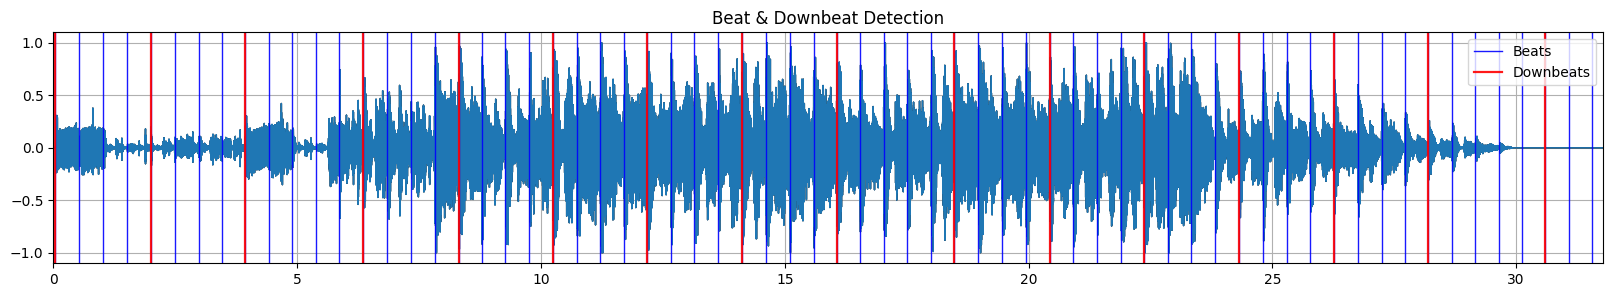

In [3]:
import random
from main import * 

hop_length = pipeline.hop_length
sr = pipeline.sample_rate
filenames = ['reference_beats.txt', 'estimated_beats.txt']
model = BeatTrackingModel().to(device)
saved_model = "best_model.pth"

if os.path.exists(saved_model):
    model.load_state_dict(torch.load(saved_model, map_location=device))
    model.to(device)
    model.eval()
else:
    print(f"Model file '{saved_model}' not found. Please train the model first.")
epoch = 0
rand_int = random.randint(0, len(test_loader) - 1)
# print(f"Randomly selected test sample index: {rand_int}")
# rand_int = 17
# Testing on unseen data loop 
# pbar = tqdm(test_loader, desc="Evaluating on Test Set", unit="sample")
beats_cumulative_metrics = {}
tempo_cumulative_metrics = {}
downbeat_cumulative_metrics = {}
genre_dict = {}

i = 0
for batch_inputs, batch_labels in test_loader:
    # batch_inputs, batch_labels = test_loader.dataset[i] if hasattr(test_loader.dataset, "indices") else 0
    flat_target = batch_labels.squeeze() 
    # Find frames where the value is roughly 1.0 (ignoring the 0.5 smeared frames)
    frame_indices = torch.where(flat_target > 0.9)[0]
    
    reference_beats = frame_indices.detach().cpu().numpy().astype(float) * (hop_length / sr)
    reference_beats = mir_eval.beat.trim_beats(reference_beats)
    
    audio_path, ref_times, positions, ref_tempo = full_dataset.get_track_info(test_loader.dataset.indices[i])
    print(f"Evaluating Track: {audio_path}\n    --> Reference Tempo: {ref_tempo} BPM \n   --> Reference Beats: {ref_times[:10]} ... \n    --> Reference Downbeat Times: {positions[:10]} ...")
    # Grab Genre from file path for later analysis
    genre = audio_path.split("/")[-2]
   
    # Run Model pass and decode with Viterbi
    beat_times, downbeats = beatTracker(audio_path, plot_predictions=True)
    
    
    # Predicted beat times -> float numpy array
    estimated_beats = np.asarray(beat_times[0], dtype=float)
    estimated_beats = mir_eval.beat.trim_beats(estimated_beats)
    # print(f"Estimated Beats: {estimated_beats[:100]}")
    
    # Predict tempo
    ibi_median = np.median(np.diff(estimated_beats)) if len(estimated_beats) > 1 else 0
    predicted_tempo = 60.0 / ibi_median if ibi_median > 0 else 0
    # print(f"Predicted Tempo: {int(predicted_tempo)} BPM")
    
    # Evaluate using numeric arrays (not strings)
    track_metrics = mir_eval.beat.evaluate(reference_beats, estimated_beats)
    
    # Evaluate tempo 
    tempo_metrics = mir_eval.tempo.evaluate(
            np.array([float(ref_tempo), float(ref_tempo)]), 
            1.0,
            np.array([float(predicted_tempo), float(predicted_tempo)])
        )
    
    # Evaluate downbeats
    ref_times_arr = np.asarray(ref_times, dtype=float).ravel()
    positions_arr = np.asarray(positions).ravel()
    downbeats_arr = np.asarray(downbeats, dtype=float).ravel()

    if len(positions_arr) == len(ref_times_arr):
        ref_downbeats = ref_times_arr[positions_arr == 1]
    else:
        ref_downbeats = np.asarray([], dtype=float)

    ref_downbeats = mir_eval.beat.trim_beats(ref_downbeats)
    downbeats_arr = mir_eval.beat.trim_beats(downbeats_arr)

    downbeat_metrics = mir_eval.beat.evaluate(ref_downbeats, downbeats_arr)
    
    # Genre Dictionary 
    
    if genre not in genre_dict:
        genre_dict[genre] = {'Beats': {}, 'Tempo': {}, 'Downbeats': {}}
    
    # Collect results and add to cumulative metrics dictionary
    for key, value in track_metrics.items():
        # print(f"{key}: {value:.4f}")
        try: 
            genre_dict[genre]['Beats'][key]
        except KeyError:
            genre_dict[genre]['Beats'][key] = []
        try:
            beats_cumulative_metrics[key]
        except KeyError:
            beats_cumulative_metrics[key] = []
        beats_cumulative_metrics[key].append(float(value))
        genre_dict[genre]['Beats'][key].append(float(value))
    
    # Collect results and add to cumulative metrics dictionary
    for key, value in tempo_metrics.items():
        # print(f"{key}: {value:.4f}")
        try: 
            genre_dict[genre]['Tempo'][key]
        except KeyError:
            genre_dict[genre]['Tempo'][key] = []
        try:
            tempo_cumulative_metrics[key]
        except KeyError:
            tempo_cumulative_metrics[key] = []
        tempo_cumulative_metrics[key].append(float(value))
        genre_dict[genre]['Tempo'][key].append(float(value))
    
    # Collect results and add to cumulative metrics dictionary
    for key, value in downbeat_metrics.items():
        # print(f"{key}: {value:.4f}")
        try: 
            genre_dict[genre]['Downbeats'][key]
        except KeyError:
            genre_dict[genre]['Downbeats'][key] = []
        try:
            downbeat_cumulative_metrics[key]
        except KeyError:
            downbeat_cumulative_metrics[key] = []
        downbeat_cumulative_metrics[key].append(float(value))
        genre_dict[genre]['Downbeats'][key].append(float(value))
    # print(genre_dict[genre].keys())
    # print('---------------------')
    # break
    i += 1
    
    ######## END OF TESTING LOOP - PRINT AVERAGE METRICS ACROSS ALL TEST TRACKS
  
# Genre Performance Analysis
with open("Genre-Performance-Analysis.txt", "w") as f:
    for genre, metrics in genre_dict.items():
        print(f"Genre: {genre}")
        for metric_type, metric_values in metrics.items():
            print(f"  {metric_type}:")
            for key, values in metric_values.items():
                avg_value = np.mean(values)
                print(f"    Average '{key}': {avg_value:.4f}")
                f.write(f"Genre: {genre} | {metric_type} | Average '{key}': {avg_value:.4f}\n")
        print('---------------------') 


# Mean of each metric across all tracks (overall performance)
beats_cumulative_metrics = {k: np.asarray(v, dtype=float) for k, v in beats_cumulative_metrics.items()}
tempo_cumulative_metrics = {k: np.asarray(v, dtype=float) for k, v in tempo_cumulative_metrics.items()}
downbeat_cumulative_metrics = {k: np.asarray(v, dtype=float) for k, v in downbeat_cumulative_metrics.items()}

with open("Cumulative-Metrics-Beats.txt", "w") as f:
    for key, arr in beats_cumulative_metrics.items():
        print(f"Average '{key}': {np.mean(arr):.4f}")
        f.write(f"Average '{key}': {np.mean(arr):.4f}\n")
print('---------------------')        
with open("Cumulative-Metrics-Tempo.txt", "w") as f:
    for key, arr in tempo_cumulative_metrics.items():
        print(f"Average '{key}': {np.mean(arr):.4f}")
        f.write(f"Average '{key}': {np.mean(arr):.4f}\n")
print('---------------------')      
with open("Cumulative-Metrics-Downbeats.txt", "w") as f:
    for key, arr in downbeat_cumulative_metrics.items():
        print(f"Average '{key}': {np.mean(arr):.4f}")
        f.write(f"Average '{key}': {np.mean(arr):.4f}\n")
print('---------------------')
print("Saved cumulative metrics")
    

    

## Follow-up Evaluation Analysis Cells

The next cells provide **post-evaluation analysis and visualization** based on the test-set results computed earlier.

### Cell 13 — Genre distribution and tempo profile of the test set
- Counts how many test tracks belong to each genre (`genre_counts`).
- Sums reference tempos per genre (`genre_tempo_sums`).
- Computes:
    - total number of test tracks,
    - percentage share of each genre in the test split,
    - average reference tempo per genre,
    - overall average reference tempo across all test tracks.
- Prints a compact summary to verify test-set balance and tempo characteristics.

### Cell 14 — Qualitative waveform inspection with beat overlays
- Loads the current `audio_path` track.
- Converts audio to a tensor waveform.
- Plots waveform with:
    - predicted beats (`estimated_beats`),
    - ground-truth beats (`reference_beats`).
- Used for visual sanity-checking of beat alignment on an example track.

### Cell 15 — Aggregate metric visualization from saved report
- Reads `Cumulative-Metrics-Beats.txt`.
- Parses metric names and their averaged values into a dictionary.
- Creates a bar chart of beat-tracking metrics (0–1 scale) with value labels.
- Provides an at-a-glance visual summary of overall beat evaluation performance.

In [23]:
from collections import defaultdict

genre_counts = defaultdict(int)
genre_tempo_sums = defaultdict(float)

# Count tracks per genre in test_dataset and accumulate reference tempo
for dataset_idx in test_dataset.indices:
    audio_path, ref_times, positions, ref_tempo = full_dataset.get_track_info(dataset_idx)
    genre = audio_path.split("/")[-2]
    genre_counts[genre] += 1
    genre_tempo_sums[genre] += float(ref_tempo)

total_tracks = sum(genre_counts.values())

# Percentage contribution per genre
genre_percentages = {
    genre: (count / total_tracks) * 100.0
    for genre, count in genre_counts.items()
}

# Average tempo per genre
genre_avg_tempos = {
    genre: (genre_tempo_sums[genre] / genre_counts[genre]) if genre_counts[genre] > 0 else 0.0
    for genre in genre_counts.keys()
}

overall_avg_tempo = (sum(genre_tempo_sums.values()) / total_tracks) if total_tracks > 0 else 0.0

print(f"Total test tracks: {total_tracks}")
print(f"Overall average tempo: {overall_avg_tempo:.2f} BPM")
for genre in sorted(genre_counts.keys()):
    print(
        f"{genre}: {genre_counts[genre]} tracks "
        f"({genre_percentages[genre]:.2f}%), Avg tempo: {genre_avg_tempos[genre]:.2f} BPM"
    )

Total test tracks: 100
Overall average tempo: 127.28 BPM
ChaChaCha: 17 tracks (17.00%), Avg tempo: 122.06 BPM
Jive: 8 tracks (8.00%), Avg tempo: 170.00 BPM
Quickstep: 10 tracks (10.00%), Avg tempo: 200.40 BPM
Rumba-American: 1 tracks (1.00%), Avg tempo: 135.00 BPM
Rumba-International: 6 tracks (6.00%), Avg tempo: 98.67 BPM
Rumba-Misc: 6 tracks (6.00%), Avg tempo: 90.00 BPM
Samba: 14 tracks (14.00%), Avg tempo: 109.71 BPM
Tango: 16 tracks (16.00%), Avg tempo: 127.25 BPM
VienneseWaltz: 6 tracks (6.00%), Avg tempo: 178.50 BPM
Waltz: 16 tracks (16.00%), Avg tempo: 86.19 BPM


odict_keys(['F-measure', 'Cemgil', 'Cemgil Best Metric Level', 'Goto', 'P-score', 'Correct Metric Level Continuous', 'Correct Metric Level Total', 'Any Metric Level Continuous', 'Any Metric Level Total', 'Information gain'])
F-measure: 0.1772
Cemgil: 0.1614
Cemgil Best Metric Level: 0.2182
Goto: 0.0000
P-score: 0.4419
Correct Metric Level Continuous: 0.0698
Correct Metric Level Total: 0.2558
Any Metric Level Continuous: 0.0698
Any Metric Level Total: 0.2791
Information gain: 0.1569
Ground Truth: [ 5.322  6.056  6.789  7.513  8.216  8.907  9.595 10.302 11.014 11.719
 12.395 13.08  13.772 14.469 15.152 15.843 16.537 17.24  17.93  18.616
 19.289 19.965 20.619 21.29  21.953 22.653 23.36  24.086 24.803 25.497
 26.175 26.836 27.51  28.179 28.87  29.558]
Beats: [ 5.15  5.74  6.33  6.92  7.51  8.1   8.69  9.27  9.85 10.43 11.01 11.6
 12.19 12.78 13.37 13.96 14.55 15.14 15.73 16.32 16.91 17.5  18.08 18.66
 19.24 19.83 20.42 21.01 21.6  22.19 22.78 23.37 23.96 24.55 25.14 25.73
 26.32 26.91 27.5

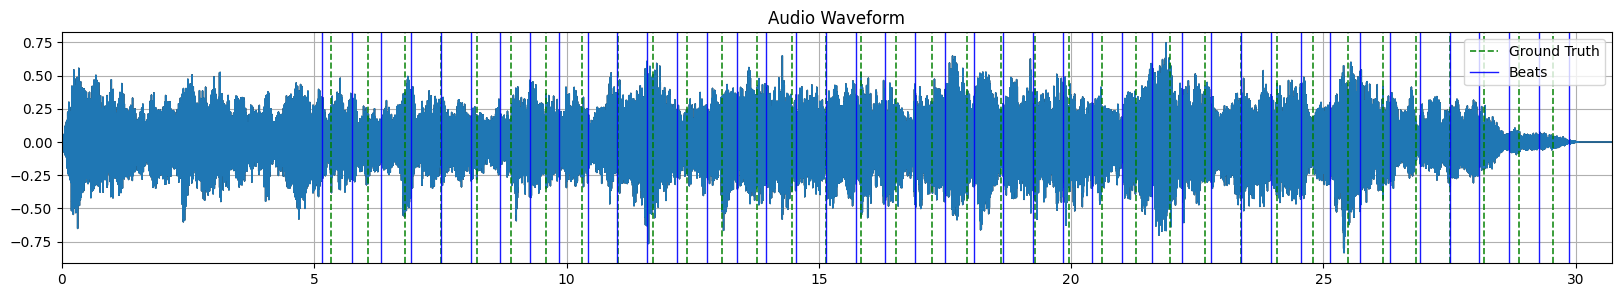

In [ ]:
audio, sr = librosa.load(audio_path, sr=None)
waveform = torch.from_numpy(audio).unsqueeze(0)
plot_waveform(waveform, sr=sr, beats=estimated_beats, ground_truth=reference_beats, title="Audio Waveform")

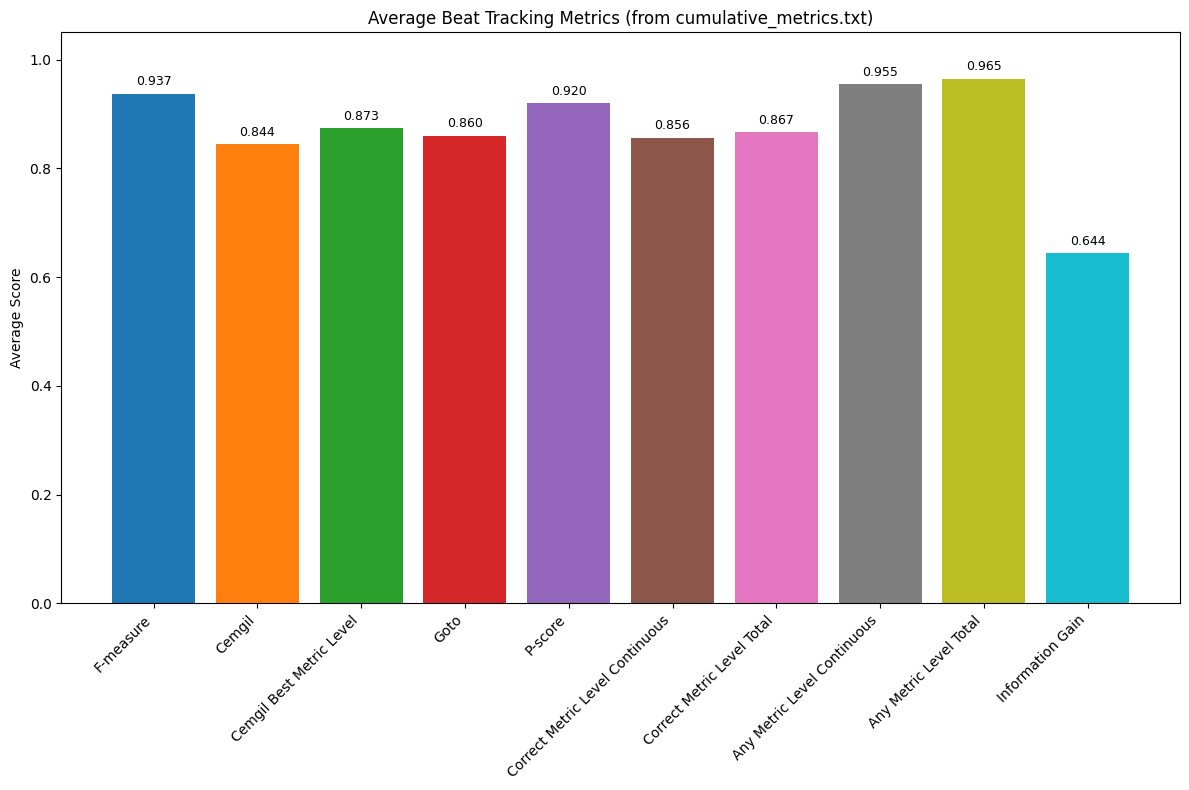

In [ ]:
metrics_from_file = {}

with open("Cumulative-Metrics-Beats.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line or ":" not in line:
            continue
        try:
            metric_name = line.split("'")[1]
            metric_value = float(line.split(":")[-1].strip())
            metrics_from_file[metric_name] = metric_value
        except (IndexError, ValueError):
            continue

if not metrics_from_file:
    print("No valid metrics found in cumulative_metrics.txt")
else:
    plt.figure(figsize=(12, 8))
    names = list(metrics_from_file.keys())
    values = list(metrics_from_file.values())

    base_colors = plt.cm.tab10.colors
    colors = [base_colors[i % len(base_colors)] for i in range(len(names))]

    bars = plt.bar(names, values, color=colors)
    plt.ylim(0, 1.05)
    plt.ylabel("Average Score")
    plt.title("Average Beat Tracking Metrics")
    plt.xticks(rotation=45, ha="right")

    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()